# Divergent Bar Plot

## Products

direction     over  under   net
group                          
clop          1263      1  1262
dispossessor  1216      3  1213
alphv           40      0    40
blackbasta      17      0    17
rhysida          4      0     4
interlock        3      0     3
blacksuit        1      0     1
cactus           1      0     1
8base            0      0     0
royal            0      0     0
ransomhub        0      0     0
medusa           0      0     0
lynx             0      0     0
lockbit3         0      0     0
hunters          0      0     0
incransom        0      0     0
abyss            0      0     0
fog              0      0     0
bianlian         0      0     0
akira            0      1    -1
dragonforce      0     48   -48
safepay          1     49   -48
qilin            2     90   -88
play             1    276  -275


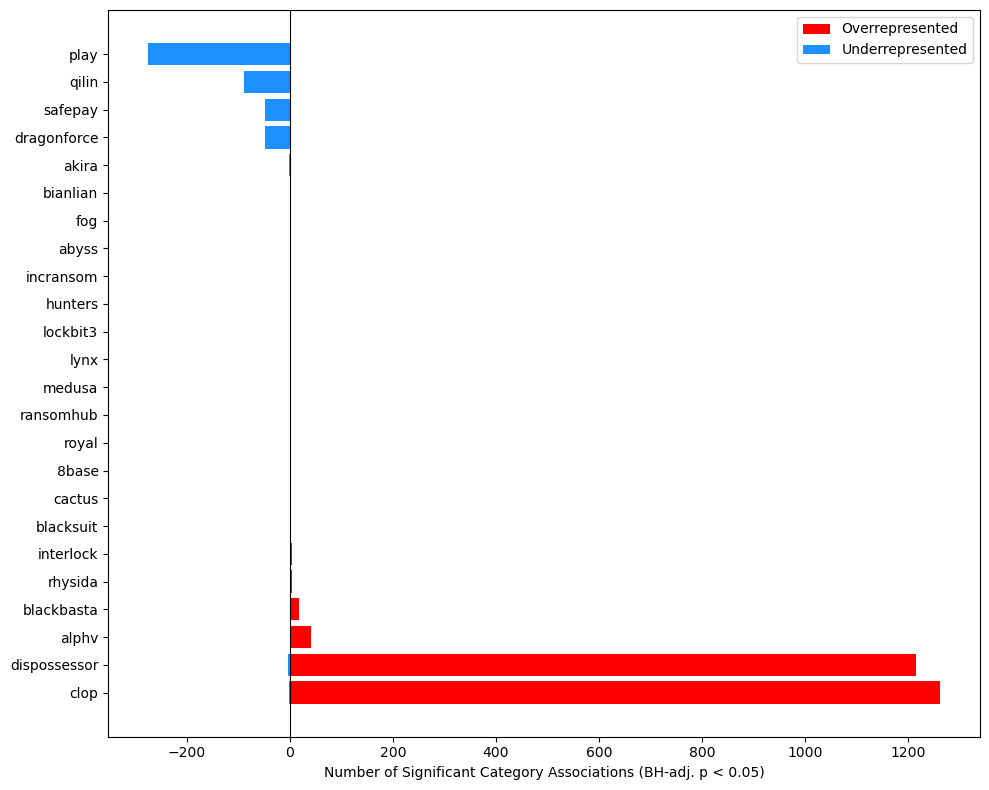

In [2]:
import matplotlib.pyplot as plt
import pandas as pd


# /Users/dmk6603/Documents/ransom_victims/9-paper/analysis_scripts/output/A7_group_product_OR.csv
# snippet of data:
# group,vendor,product,a,b,c,d,grp_pct,oth_pct,OR,ci_lo,ci_hi,p,p_adj,significant
# lockbit3,NGINX,Web Server,239,283,2270,2398,45.785440613026815,48.628963153384746,0.892143646580844,0.7444157412555181,1.069857151595409,0.22993199201873557,0.8232352355149138,False
# lockbit3,The jQuery Foundation Inc,jQuery UI,304,218,2584,2084,58.23754789272031,55.35561268209083,1.1246627091203454,0.9359229720425931,1.349840113936521,0.21024154004512874,0.7901013091194311,False

df = pd.read_csv('/Users/dmk6603/Documents/ransom_victims/9-paper/analysis_scripts/output/A7_group_product_OR.csv')
df['significant'] = df['p_adj'] < 0.05
df['direction'] = df.apply(lambda row: 'over' if row['OR'] > 1 else 'under', axis=1)
df['count'] = df.apply(lambda row: 1 if row['significant'] else 0, axis=1)
summary = df.groupby(['group', 'direction'])['count'].sum().unstack(fill_value=0)
summary['net'] = summary['over'] - summary['under']
summary = summary.sort_values('net', ascending=False)
print(summary)


groups = summary.index.tolist()  # i tuoi gruppi
over = summary['over'].tolist()    # conteggi overrepresented
under = (-summary['under']).tolist()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(groups, over, color='red', label='Overrepresented')
ax.barh(groups, under, color='dodgerblue', label='Underrepresented')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Number of Significant Category Associations (BH-adj. p < 0.05)')
ax.legend()
plt.tight_layout()
plt.savefig('diverging_bar.png', dpi=300)
plt.show()

# Vendors

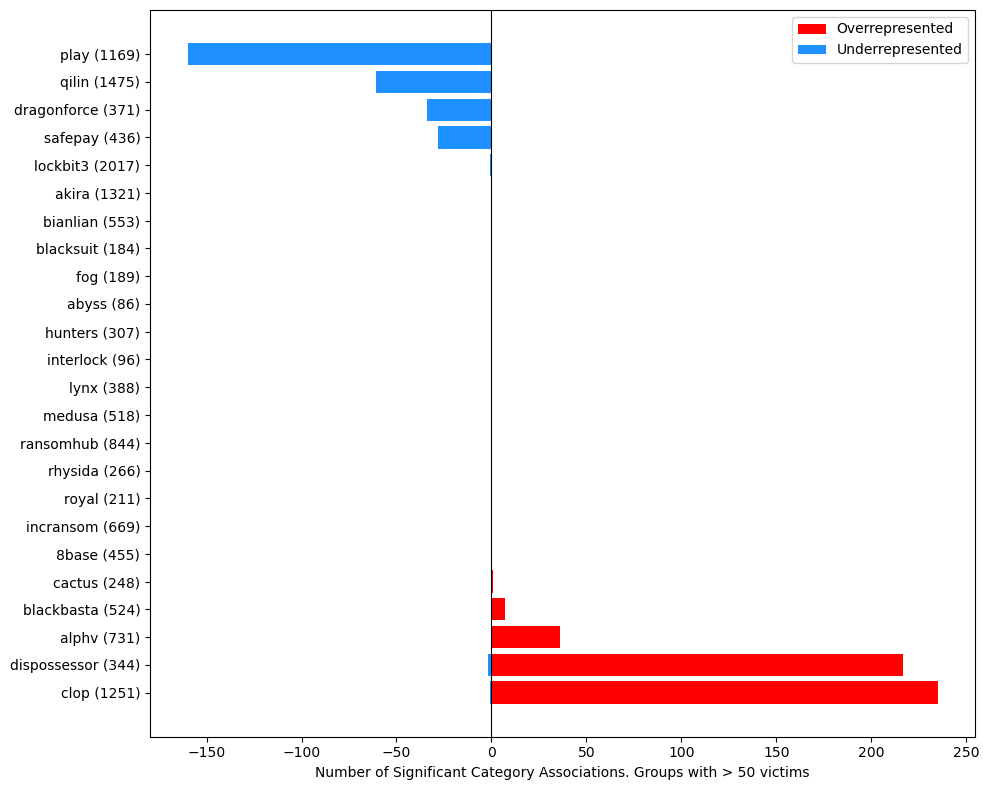

In [5]:
import matplotlib.pyplot as plt
import pandas as pd


# /Users/dmk6603/Documents/ransom_victims/9-paper/analysis_scripts/output/A7_group_product_OR.csv
# snippet of data:
# group,vendor,product,a,b,c,d,grp_pct,oth_pct,OR,ci_lo,ci_hi,p,p_adj,significant
# lockbit3,NGINX,Web Server,239,283,2270,2398,45.785440613026815,48.628963153384746,0.892143646580844,0.7444157412555181,1.069857151595409,0.22993199201873557,0.8232352355149138,False
# lockbit3,The jQuery Foundation Inc,jQuery UI,304,218,2584,2084,58.23754789272031,55.35561268209083,1.1246627091203454,0.9359229720425931,1.349840113936521,0.21024154004512874,0.7901013091194311,False

# /Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/groups.csv4
# group,altname,victims
# 0apt,,0
# 0mega,,7

df = pd.read_csv('/Users/dmk6603/Documents/ransom_victims/9-paper/analysis_scripts/output/A6_group_vendor_OR.csv')
groups_df = pd.read_csv('/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/groups.csv')

df['significant'] = df['p_adj'] < 0.05
df['direction'] = df.apply(lambda row: 'over' if row['OR'] > 1 else 'under', axis=1)
df['count'] = df.apply(lambda row: 1 if row['significant'] else 0, axis=1)

summary = df.groupby(['group', 'direction'])['count'].sum().unstack(fill_value=0)
summary['net'] = summary['over'] - summary['under']
summary = summary.sort_values('net', ascending=False)

# Merge victim counts from groups.csv
victim_map = groups_df.set_index('group')['victims'].to_dict()
summary['victims'] = summary.index.map(lambda g: victim_map.get(g, 0))

# Build y-axis labels with victim count in parentheses
labels = [f"{g} ({int(summary.loc[g, 'victims'])})" for g in summary.index]

over = summary['over'].tolist()
under = (-summary['under']).tolist()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(labels, over, color='red', label='Overrepresented')
ax.barh(labels, under, color='dodgerblue', label='Underrepresented')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Number of Significant Category Associations. Groups with > 50 victims')
ax.legend()
plt.tight_layout()
plt.savefig('diverging_bar.png', dpi=300)
plt.show()

# Categories

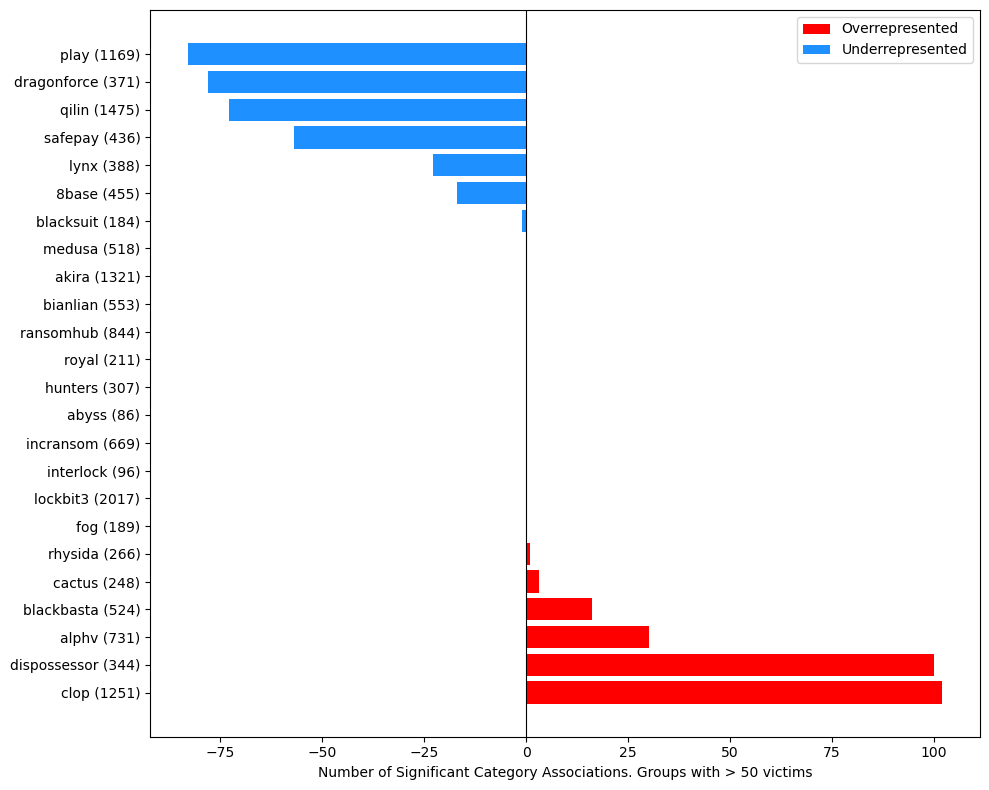

In [6]:
import matplotlib.pyplot as plt
import pandas as pd


# /Users/dmk6603/Documents/ransom_victims/9-paper/analysis_scripts/output/A7_group_product_OR.csv
# snippet of data:
# group,vendor,product,a,b,c,d,grp_pct,oth_pct,OR,ci_lo,ci_hi,p,p_adj,significant
# lockbit3,NGINX,Web Server,239,283,2270,2398,45.785440613026815,48.628963153384746,0.892143646580844,0.7444157412555181,1.069857151595409,0.22993199201873557,0.8232352355149138,False
# lockbit3,The jQuery Foundation Inc,jQuery UI,304,218,2584,2084,58.23754789272031,55.35561268209083,1.1246627091203454,0.9359229720425931,1.349840113936521,0.21024154004512874,0.7901013091194311,False

# /Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/groups.csv4
# group,altname,victims
# 0apt,,0
# 0mega,,7

df = pd.read_csv('/Users/dmk6603/Documents/ransom_victims/9-paper/analysis_scripts/output/A5_group_category_OR.csv')
groups_df = pd.read_csv('/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/groups.csv')

df['significant'] = df['p_adj'] < 0.05
df['direction'] = df.apply(lambda row: 'over' if row['OR'] > 1 else 'under', axis=1)
df['count'] = df.apply(lambda row: 1 if row['significant'] else 0, axis=1)

summary = df.groupby(['group', 'direction'])['count'].sum().unstack(fill_value=0)
summary['net'] = summary['over'] - summary['under']
summary = summary.sort_values('net', ascending=False)

# Merge victim counts from groups.csv
victim_map = groups_df.set_index('group')['victims'].to_dict()
summary['victims'] = summary.index.map(lambda g: victim_map.get(g, 0))

# Build y-axis labels with victim count in parentheses
labels = [f"{g} ({int(summary.loc[g, 'victims'])})" for g in summary.index]

over = summary['over'].tolist()
under = (-summary['under']).tolist()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(labels, over, color='red', label='Overrepresented')
ax.barh(labels, under, color='dodgerblue', label='Underrepresented')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Number of Significant Category Associations. Groups with > 50 victims')
ax.legend()
plt.tight_layout()
plt.savefig('diverging_bar.png', dpi=300)
plt.show()